In [21]:
import os
import glob
import json
import yaml
import shutil
import random
import numpy as np
import pandas as pd
from datetime import datetime
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split

In [2]:
save_dir = f"./Processed/"
shutil.rmtree(save_dir, ignore_errors = True)
os.makedirs(save_dir, exist_ok = True)

In [3]:
def stratified_split_by_images(df, val_ratio, random_state=42):
    """
    Split dataset into train/validation using:
    - Image-level grouping (prevents leakage)
    - Size-based stratification (avg bbox area)
    - Class coverage fixing (ensures all classes in validation)
    """
    df = df.copy()

    image_stats = df.groupby("image_id").agg({"bbox_area": ["mean", "count"]})

    image_stats.columns = ["avg_bbox_area", "num_objects"]
    image_stats = image_stats.reset_index()

    image_stats["size_category"] = pd.qcut(
        image_stats["avg_bbox_area"],
        q=3,
        duplicates="drop")
    
    # image_stats["density_category"] = pd.qcut(
    #     image_stats["num_objects"],
    #     q=3,
    #     duplicates="drop")

    train_image_ids, val_image_ids = train_test_split(
        image_stats["image_id"],
        test_size=val_ratio,
        stratify=image_stats["size_category"],
        random_state=random_state
    )

    train_image_ids = set(train_image_ids.values)
    val_image_ids   = set(val_image_ids.values)

    all_classes = set(df["type_id"].unique())

    val_classes = set(df[df["image_id"].isin(val_image_ids)]["type_id"].unique())
    missing_classes = all_classes - val_classes
    
    for type_id in missing_classes:
        candidate_images = df[(df["type_id"] == type_id) & (df["image_id"].isin(train_image_ids))]["image_id"].unique()

        if len(candidate_images) <= 1:
            continue

        np.random.seed(random_state)
        np.random.shuffle(candidate_images)

        num_to_move = min(3, len(candidate_images) - 1)
        selected_images = candidate_images[:num_to_move]

        for img in selected_images:
            train_image_ids.remove(img)
            val_image_ids.add(img)

    train_df = df[df["image_id"].isin(train_image_ids)].copy()
    val_df   = df[df["image_id"].isin(val_image_ids)].copy()

    # any leakage
    assert len(train_image_ids & val_image_ids) == 0, "Data leakage detected!"

    train_classes = set(train_df["type_id"])
    val_classes   = set(val_df["type_id"])

    print("Split Summary")
    print(f"Train Images: {len(train_image_ids)}")
    print(f"Val Images: {len(val_image_ids)}")

    print("\n Class Coverage")
    print(f"Total Classes: {len(all_classes)}")
    print(f"Train Classes: {len(train_classes)}")
    print(f"Val Classes: {len(val_classes)}")

    missing_after = all_classes - val_classes
    if missing_after:
        print(f"Still Missing in Val: {missing_after}")
    else:
        print("All classes present in validation")

    train_df["split"] = "train"
    val_df["split"]= "val"
    return pd.concat([train_df, val_df])

In [4]:
df = pd.read_csv("../dataset/Original/train_labels/xview_labels.csv")
split_df= stratified_split_by_images(df, val_ratio=0.15)

Split Summary
Train Images: 713
Val Images: 133

 Class Coverage
Total Classes: 60
Train Classes: 60
Val Classes: 60
All classes present in validation


In [5]:
split_df.head()

,image_id,type_id,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,image_height,image_width,split
0,2355.tif,73,2712,1145,2739,1177,34,32,1088,2667.0,2739.0,train
1,2355.tif,73,2720,2233,2739,2288,40,55,2200,2667.0,2739.0,train
2,2355.tif,73,2687,1338,2739,1399,53,61,3233,2667.0,2739.0,train
3,2355.tif,73,2691,1201,2730,1268,39,67,2613,2667.0,2739.0,train
4,2355.tif,73,2671,838,2714,869,43,31,1333,2667.0,2739.0,train


**Image Tiling**

In [6]:
def get_positions(length, tile_size, stride):
    positions = []
    pos = 0

    while pos + tile_size <= length:
        positions.append(pos)
        pos += stride

    last_pos = length - tile_size
    if len(positions) == 0:
        positions.append(last_pos)
    elif last_pos - positions[-1] < stride:
        positions[-1] = last_pos
    else:
        positions.append(last_pos)

    return positions


def tile_image(image, tile_size=512, overlap=0.25):
    h, w = image.shape[:2]
    stride = int(tile_size * (1 - overlap))

    y_positions = get_positions(h, tile_size, stride)
    x_positions = get_positions(w, tile_size, stride)

    tiles = []
    for y in y_positions:
        for x in x_positions:
            tile = image[y:y+tile_size, x:x+tile_size]
            tiles.append((tile, (x, y)))

    return tiles


def process_tiling_pipeline(df, root_dir, output_dir, tile_size=512, overlap=0.25):#, threshold=0.001):
    os.makedirs(output_dir, exist_ok=True)

    all_rows = []

    for name, group in df.groupby("image_id"):
        #print(f"Processing: {name}")

        # Load image
        img_path = os.path.join(root_dir, name)
        img = Image.open(img_path).convert("RGB")
        img_arr = np.array(img)

        # Get tiles
        tiles = tile_image(img_arr, tile_size, overlap)

        # Convert bbox to numpy
        bboxes = group[["xmin","ymin","xmax","ymax","type_id","split"]].values

        for tile, (tile_x, tile_y) in tiles:

            # Spatial filtering
            mask = ~((bboxes[:,2] < tile_x) |
                     (bboxes[:,0] > tile_x + tile_size) |
                     (bboxes[:,3] < tile_y) |
                     (bboxes[:,1] > tile_y + tile_size))

            candidate_boxes = bboxes[mask]
            
            new_bboxes = []
            for xmin, ymin, xmax, ymax, type_id, split in candidate_boxes:

                # Shift
                xmin -= tile_x
                ymin -= tile_y
                xmax -= tile_x
                ymax -= tile_y

                # Clip
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(tile_size, xmax)
                ymax = min(tile_size, ymax)

                # Validate
                if xmin >= xmax or ymin >= ymax:
                    continue

                # Area filtering
                # area = (xmax - xmin) * (ymax - ymin)
                # if area / (tile_size * tile_size) < threshold:
                #     continue

                im_id = os.path.splitext(name)[0]
                tile_img_id = f"{im_id}_{tile_x}_{tile_y}.png"

                new_bboxes.append([name,tile_img_id,xmin,ymin,xmax,ymax,type_id,split])

            # Skip empty tiles
            if len(new_bboxes) == 0:
                #print(f"Empty Tiles in {name}")
                continue

            # Save tile
            tile_img = Image.fromarray(tile)
            os.makedirs(os.path.join(output_dir,split), exist_ok=True)
            tile_img.save(os.path.join(output_dir, split, tile_img_id))

            all_rows.extend(new_bboxes)

    # output df
    new_df = pd.DataFrame(
        all_rows,
        columns=["image_id", "tile_image_id", "xmin", "ymin", "xmax", "ymax", "type_id", "split"]
    )
    
    return new_df


tiled_df= process_tiling_pipeline(split_df, 
                                  root_dir= "../dataset/Original/train_images", 
                                  output_dir= "../dataset/Processed/images",
                                  tile_size= 512, 
                                  overlap= 0.25)


In [7]:
def fetch_id2label(txt_path):
    id2label= {}
    with open(txt_path, "r") as f:
        for line in f:
            txt= line.strip().split(':')
            id2label[int(txt[0])] = txt[1]
    return id2label

def fetch_id2clsmap(df):
    id2clsmap= {}
    count= 0
    for type_id in np.unique(df.type_id):
        id2clsmap[type_id] = count
        count+=1
    return id2clsmap


txt_file= "../Dataset/Original/xview_class_labels.txt"
id2label= fetch_id2label(txt_file)
id2clsmap= fetch_id2clsmap(tiled_df)
tiled_df["label"]= tiled_df["type_id"].map(id2clsmap)
tiled_df["category"]= tiled_df["type_id"].map(id2label)

In [8]:
result = (
    tiled_df[['label', 'category']]
    .drop_duplicates()
    .sort_values(by='label')
)

label2cls= dict(result.values)

In [9]:
tiled_df.to_csv("../dataset/Processed/annotations.csv")

**Export Utils**

In [10]:
def export_to_yolo(annot_df, output_dir, tile_size):
    os.makedirs(output_dir, exist_ok=True)

    for name, group in annot_df.groupby("tile_image_id"):

        # Extract values
        bboxes = group[["xmin","ymin","xmax","ymax"]].values.astype(np.float32)
        class_ids = group["label"].values.astype(int)
        split= np.unique(group["split"].values)
        if len(split) > 1: raise ValueError(f"Invalid Split. tile_image_id: {name} in dataframe has multiple splits for an image")

        # Convert to YOLO format
        x_center = (bboxes[:, 0] + bboxes[:, 2]) / 2.0
        y_center = (bboxes[:, 1] + bboxes[:, 3]) / 2.0
        width    = (bboxes[:, 2] - bboxes[:, 0])
        height   = (bboxes[:, 3] - bboxes[:, 1])

        # Normalize
        x_center /= tile_size
        y_center /= tile_size
        width    /= tile_size
        height   /= tile_size

        # Create txt file name
        txt_name = os.path.splitext(name)[0] + ".txt"
        os.makedirs(os.path.join(output_dir, split.item()), exist_ok=True)
        txt_path = os.path.join(output_dir, split.item(), txt_name)

        # Write to file
        with open(txt_path, "w") as f:
            for cls, xc, yc, w, h in zip(class_ids, x_center, y_center, width, height):
                f.write(f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
    print("YOLO txt exported successfully.")


def export_to_coco(annot_df, output_dir, tile_size):
    os.makedirs(output_dir, exist_ok=True)
    
    coco_json= {
        "info": {
        "description": "xView Satellite Imagery Dataset (Tiled)",
        "date_created": datetime.now().isoformat(),
        },
        "images": [],
        "annotations": [],
        "categories": []
    }

    # store categories metadata
    categories= annot_df[["label", "category"]].drop_duplicates().sort_values("label")
    for row in categories.itertuples(index=False):
        coco_json["categories"].append({
            "id": int(row.label),
            "name": row.category,
            "supercategory": "none"
        })

    # store images metadata
    image2id= {}
    images= []
    unique_tiles = annot_df["tile_image_id"].unique()
    for i, tile_image_id in enumerate(unique_tiles):
        images.append({"id": i,
                       "file_name": tile_image_id,
                       "width": tile_size,
                       "height": tile_size
                      })
        image2id[tile_image_id]= i

    coco_json["images"]= images
    
    # store annotations metadata
    annot_id= 0
    annotations = []
    for row in annot_df.itertuples(index=False):
        xmin = row.xmin
        ymin = row.ymin
        xmax = row.xmax
        ymax = row.ymax

        width = xmax - xmin
        height = ymax - ymin
        if width <= 0 or height <= 0:
            continue
        area = width * height
        
        tile_image_id= row.tile_image_id
        category_id= row.label

        annotations.append({"id": annot_id,
                            "image_id": image2id[tile_image_id],
                            "category_id": int(category_id),
                            "bbox": [xmin, ymin, width, height],
                            "area": area,
                            "segmentation": [],
                            "iscrowd": 0
                           })
        annot_id+=1
        
    coco_json["annotations"]= annotations    
    
    # 5. Export to JSON
    output_path= os.path.join(output_dir, "annotations.json")
    with open(output_path, 'w') as f:
        json.dump(coco_json, f, indent=4)
    
    print("COCO JSON exported successfully.")
    return coco_json



In [11]:
export_to_yolo(tiled_df, output_dir= "../dataset/Processed/labels", tile_size=512)
#export_to_coco(tiled_df, output_dir= "../Dataset/Processed/", tile_size=512)

YOLO txt exported successfully.


**store data.yaml Config**

In [14]:
config = {
    'path': '../dataset/Processed',
    'train': 'images/train',
    'val': 'images/val',
    'names': label2cls
}

with open('../dataset/data.yaml', 'w') as f: yaml.dump(config, f, sort_keys = False)

**Visualize**

In [23]:
def show_image(image_path, df, class_labels):
    df= df.copy()
    df["category"]= df["type_id"].map(class_labels)
    
    # load image
    image= Image.open(image_path)
    draw = ImageDraw.Draw(image)
    
    image_id= image_path.split("/")[-1]
    bbox_df= df[df["tile_image_id"] == image_id]

    for idx, row in bbox_df.iterrows():
        xmin= row["xmin"]
        ymin= row["ymin"]
        xmax= row["xmax"]
        ymax= row["ymax"]
        type_id= row["type_id"]

        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)
        draw.text((xmin, ymin), str(type_id) , fill="yellow")
        
    return image


def visualize_yolo_annotation(image_dir, label_dir, image_path=None):

    #random image if not provided
    if image_path is None:
        images = [f for f in os.listdir(image_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
        image_name = random.choice(images)
        image_path = os.path.join(image_dir, image_name)
    else:
        image_name = os.path.basename(image_path)

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    draw = ImageDraw.Draw(img)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(label_dir, label_name)

    if not os.path.exists(label_path):
        print(f"No label file found for {image_name}")
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, bw, bh = map(float, line.strip().split())

        xc *= w
        yc *= h
        bw *= w
        bh *= h

        xmin = int(xc - bw / 2)
        ymin = int(yc - bh / 2)
        xmax = int(xc + bw / 2)
        ymax = int(yc + bh / 2)

        # Draw rectangle
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)

        # Draw class id
        draw.text((xmin, ymin), str(int(cls)), fill="yellow")

    return img

def visualize_coco_annotation(image_dir, coco_json_path, image_id=None):

    with open(coco_json_path, "r") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]

    if image_id is None:
        img_info = random.choice(images)
    else:
        img_info = next(img for img in images if img["id"] == image_id)

    file_name = img_info["file_name"]
    image_id = img_info["id"]

    image_path = os.path.join(image_dir, file_name)
    img = Image.open(image_path).convert("RGB")

    draw = ImageDraw.Draw(img)

    anns = [ann for ann in annotations if ann["image_id"] == image_id]

    for ann in anns:
        x, y, w, h = ann["bbox"]

        xmin = int(x)
        ymin = int(y)
        xmax = int(x + w)
        ymax = int(y + h)

        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)

        draw.text((xmin, ymin), str(ann["category_id"]), fill="yellow")

    return img

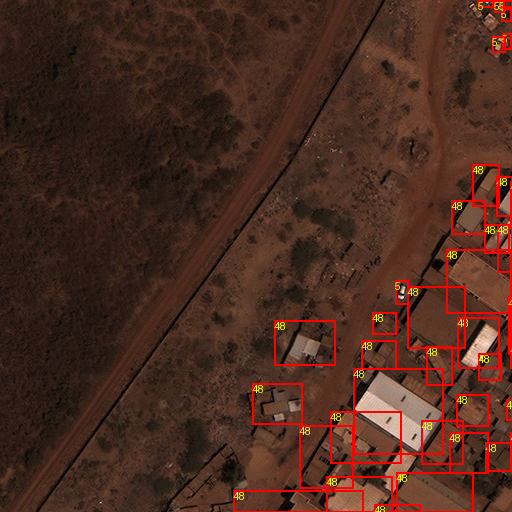

In [31]:
# visualize
visualize_yolo_annotation(image_dir= "../dataset/Processed/images/train", label_dir="../dataset/Processed/labels/train")
#visualize_coco_annotation(image_dir= "../dataset/Processed/images/train", coco_json_path="../dataset/Processed/labels/train")